# Entrenamiento de Redes Neuronales - Ejercicios

**Instrucciones:**
- Completa las secciones marcadas con `# TODO`
- Ejecuta cada celda para verificar que funciona
- Cada ejercicio tiene pistas si te trabas

**Solo usamos:** `numpy` y `matplotlib`

**Integrantes:**
Marlon Omar Salazar Alvarado
Paul David Delgado Vergara



In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

---
## Ejercicio 1: Funciones de Activación

Implementa las 3 funciones de activación principales y sus derivadas.
Luego grafícalas para comparar visualmente.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Ejercicio 1: Funciones de Activación
# ============================================================

def sigmoid(z):
    """
    Sigmoide: σ(z) = 1 / (1 + e^(-z))
    """
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    """
    Derivada: σ'(z) = σ(z) * (1 - σ(z))
    """
    s = sigmoid(z)
    return s * (1 - s)

def relu(z):
    """
    ReLU: R(z) = max(0, z)
    """
    return np.maximum(0, z)

def relu_derivative(z):
    """
    Derivada: R'(z) = 1 si z > 0, 0 si z <= 0
    """
    return (z > 0).astype(float)

def tanh(z):
    """
    Tanh: tanh(z) = (e^z - e^(-z)) / (e^z + e^(-z))
    """
    return np.tanh(z)

def tanh_derivative(z):
    """
    Derivada: tanh'(z) = 1 - tanh(z)^2
    """
    return 1 - np.tanh(z)**2

In [5]:
# --- Verificar implementación ---
z_test = np.array([-2, -1, 0, 1, 2])

print("Sigmoid:", sigmoid(z_test))   # Esperado: [0.119, 0.269, 0.5, 0.731, 0.881]
print("ReLU:   ", relu(z_test))      # Esperado: [0, 0, 0, 1, 2]
print("Tanh:   ", tanh(z_test))      # Esperado: [-0.964, -0.762, 0, 0.762, 0.964]

Sigmoid: [0.11920292 0.26894142 0.5        0.73105858 0.88079708]
ReLU:    [0 0 0 1 2]
Tanh:    [-0.96402758 -0.76159416  0.          0.76159416  0.96402758]


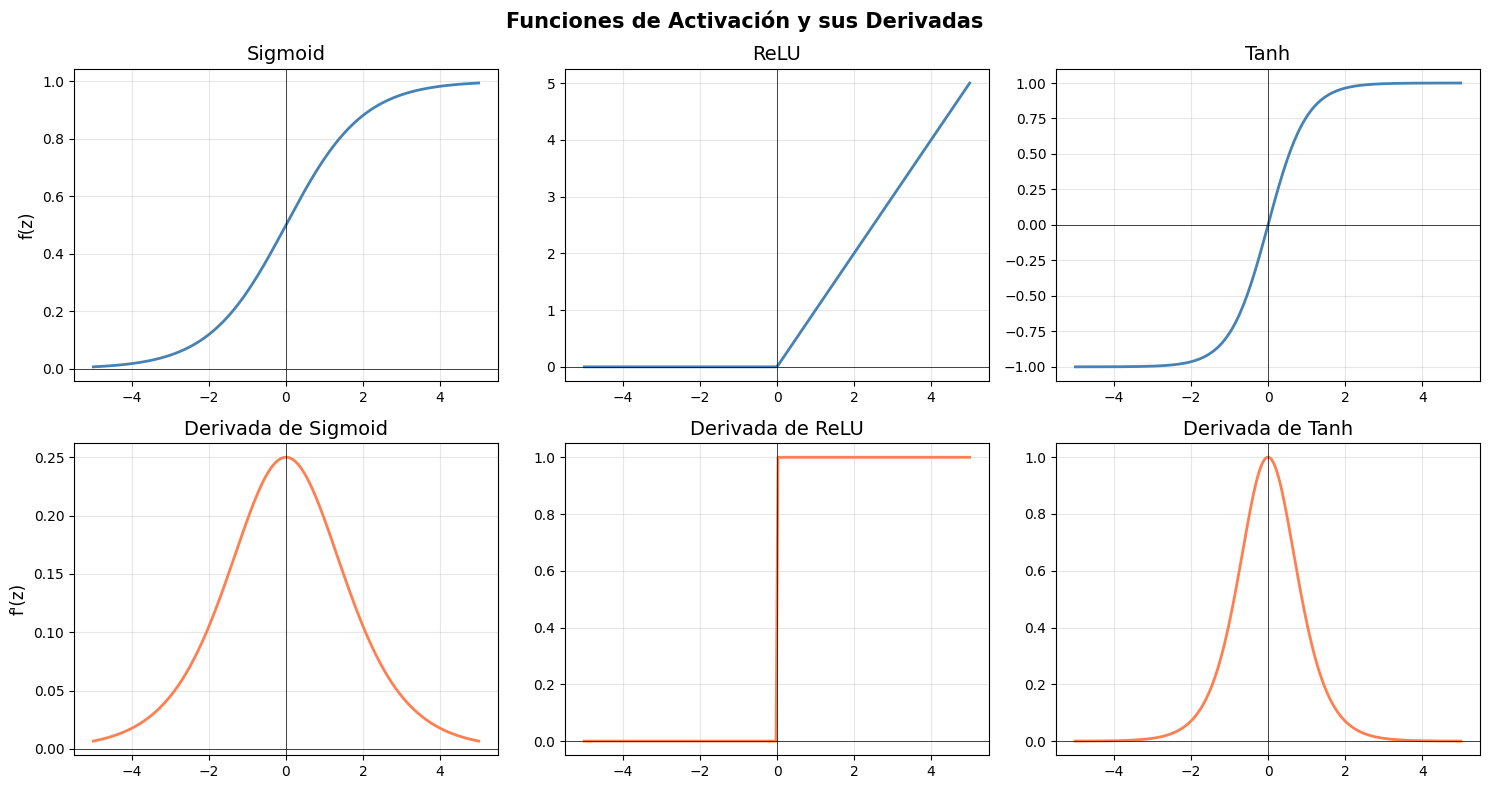

In [6]:
# --- Graficar las 3 funciones y sus derivadas ---
z = np.linspace(-5, 5, 200)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

funciones = [
    (sigmoid, sigmoid_derivative, "Sigmoid"),
    (relu, relu_derivative, "ReLU"),
    (tanh, tanh_derivative, "Tanh"),
]

for i, (func, deriv, name) in enumerate(funciones):
    axes[0, i].plot(z, func(z), linewidth=2, color='steelblue')
    axes[0, i].set_title(f'{name}', fontsize=14)
    axes[0, i].grid(True, alpha=0.3)
    axes[0, i].axhline(y=0, color='k', linewidth=0.5)
    axes[0, i].axvline(x=0, color='k', linewidth=0.5)

    axes[1, i].plot(z, deriv(z), linewidth=2, color='coral')
    axes[1, i].set_title(f"Derivada de {name}", fontsize=14)
    axes[1, i].grid(True, alpha=0.3)
    axes[1, i].axhline(y=0, color='k', linewidth=0.5)
    axes[1, i].axvline(x=0, color='k', linewidth=0.5)

axes[0, 0].set_ylabel('f(z)', fontsize=12)
axes[1, 0].set_ylabel("f'(z)", fontsize=12)

plt.suptitle('Funciones de Activación y sus Derivadas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Pregunta para reflexionar:**
- ¿Por qué la derivada de la sigmoide es tan pequeña en los extremos?
por que cuando la sigmoide se acerca a 0 o 1 la curva se vuelve casi plana entonces la pendiente (derivada) es muy pequeña
- ¿Qué problema puede causar esto en redes profundas? (pista: vanishing gradient)
Puede causar vanishing gradient, es decir, los gradientes se hacen tan pequeños que las primeras capas casi no aprenden.
- ¿Por qué ReLU es la más usada en capas ocultas hoy en día?
Porque aprende más rápido, evita mejor el vanishing gradient y funciona muy bien en problemas no lineales como el de las lunas que trabajaste.

---
## Ejercicio 2: Perceptrón para compuertas lógicas

Implementa un perceptrón y entrénalo para aprender las compuertas **OR** y **AND**.
Después intenta con **XOR** y observa qué pasa.

In [7]:
# Datasets de compuertas lógicas
X_logic = np.array([[0, 0],
                     [0, 1],
                     [1, 0],
                     [1, 1]])

y_AND = np.array([0, 0, 0, 1])
y_OR  = np.array([0, 1, 1, 1])
y_XOR = np.array([0, 1, 1, 0])

In [8]:
class PerceptronLogic:
    def __init__(self, lr=5.0):
        self.w = np.random.randn(2) * 0.01
        self.b = 0.0
        self.lr = lr

    def forward(self, X):
        """
        Calcula la salida: sigmoid(X·w + b)
        """
        z = X @ self.w + self.b
        return 1 / (1 + np.exp(-z))

    def train(self, X, y, epochs=1000):
        for epoch in range(epochs):
            # 1. Calcular predicción
            pred = self.forward(X)

            # 2. Error
            error = pred - y

            # 3. Gradiente de w
            grad_w = X.T @ (error * pred * (1 - pred)) / len(y)

            # 4. Gradiente de b
            grad_b = np.mean(error * pred * (1 - pred))

            # 5. Actualizar parámetros
            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b

In [9]:
# --- Entrenar y probar con cada compuerta ---

for name, y_target in [("AND", y_AND), ("OR", y_OR), ("XOR", y_XOR)]:
    np.random.seed(42)
    p = PerceptronLogic(lr=5.0)
    p.train(X_logic, y_target, epochs=2000)

    print(f"\n=== Compuerta {name} ===")
    for xi, yi in zip(X_logic, y_target):
        pred = p.forward(xi.reshape(1, -1))[0]
        print(f"  {xi} → pred: {pred:.3f} | esperado: {yi} | {'✓' if round(pred) == yi else '✗'}")


=== Compuerta AND ===
  [0 0] → pred: 0.000 | esperado: 0 | ✓
  [0 1] → pred: 0.034 | esperado: 0 | ✓
  [1 0] → pred: 0.034 | esperado: 0 | ✓
  [1 1] → pred: 0.960 | esperado: 1 | ✓

=== Compuerta OR ===
  [0 0] → pred: 0.034 | esperado: 0 | ✓
  [0 1] → pred: 0.979 | esperado: 1 | ✓
  [1 0] → pred: 0.979 | esperado: 1 | ✓
  [1 1] → pred: 1.000 | esperado: 1 | ✓

=== Compuerta XOR ===
  [0 0] → pred: 0.500 | esperado: 0 | ✓
  [0 1] → pred: 0.500 | esperado: 1 | ✗
  [1 0] → pred: 0.500 | esperado: 1 | ✗
  [1 1] → pred: 0.500 | esperado: 0 | ✓


**Preguntas:**
- ¿AND y OR se aprenden correctamente? Sí, se aprenden bien porque ambas compuertas son linealmente separables, es decir, una sola línea puede separar los 0 de los 1.
- ¿Qué pasa con XOR? ¿Por qué falla? XOR falla porque sus puntos están cruzados y no se pueden separar con una sola línea recta, por eso un perceptrón simple no logra aprenderlo.
- ¿Cuántas líneas rectas necesitaría para separar XOR? (pista: ver diapositiva 5) Necesita mínimo 2 líneas rectas, o visto en redes neuronales, más de una neurona/capa.


---
## Ejercicio 3: Funciones de Coste

Implementa las funciones de coste MSE y Binary Cross-Entropy.
Compara cómo se comportan con diferentes predicciones.

In [10]:
def mse_loss(y_true, y_pred):
    """
    Error Cuadrático Medio: MSE = (1/N) * Σ(y_true - y_pred)²
    """
    return np.mean((y_true - y_pred) ** 2)

def bce_loss(y_true, y_pred):
    """
    Binary Cross-Entropy: L = -(1/N) * Σ[y*log(ŷ) + (1-y)*log(1-ŷ)]
    Usa eps = 1e-8 para evitar log(0)
    """
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

In [11]:
# --- Verificar ---
y_true = np.array([1, 0, 1, 1, 0])

# Predicción buena
y_good = np.array([0.9, 0.1, 0.8, 0.95, 0.05])
# Predicción mala
y_bad  = np.array([0.2, 0.8, 0.3, 0.4, 0.9])

print("Predicción BUENA:")
print(f"  MSE:  {mse_loss(y_true, y_good):.4f}")
print(f"  BCE:  {bce_loss(y_true, y_good):.4f}")

print("\nPredicción MALA:")
print(f"  MSE:  {mse_loss(y_true, y_bad):.4f}")
print(f"  BCE:  {bce_loss(y_true, y_bad):.4f}")

print("\n→ Ambos losses deben ser MENORES en la predicción buena")

Predicción BUENA:
  MSE:  0.0130
  BCE:  0.1073

Predicción MALA:
  MSE:  0.5880
  BCE:  1.5283

→ Ambos losses deben ser MENORES en la predicción buena


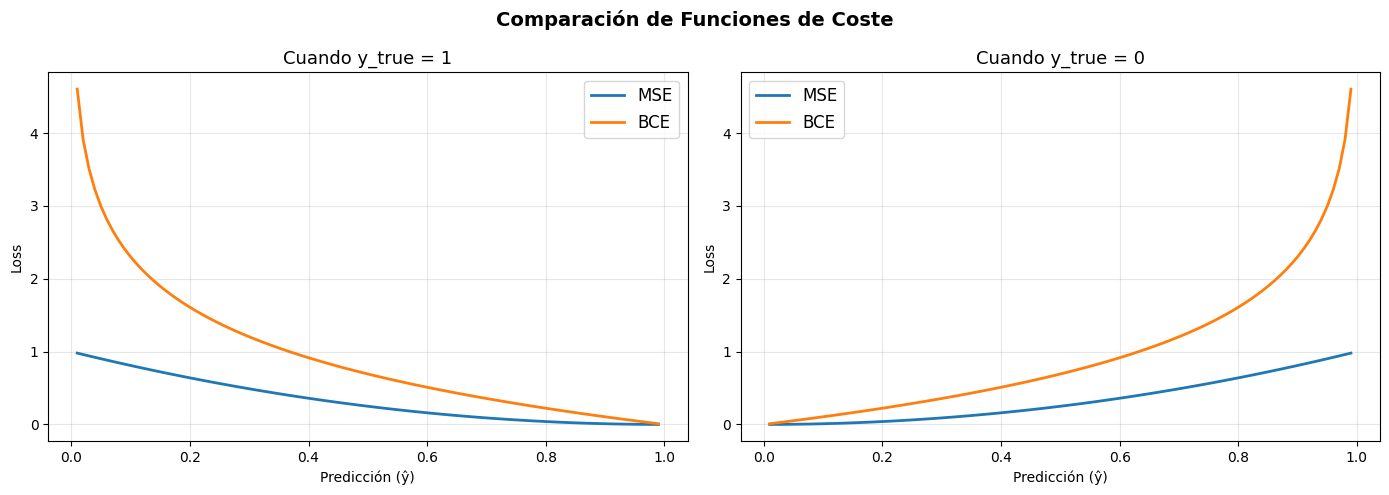

In [12]:
# --- Visualizar cómo varía el loss según la predicción ---
y_pred_range = np.linspace(0.01, 0.99, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cuando y_true = 1
axes[0].plot(y_pred_range, [(1 - p)**2 for p in y_pred_range], label='MSE', linewidth=2)
axes[0].plot(y_pred_range, [-np.log(p) for p in y_pred_range], label='BCE', linewidth=2)
axes[0].set_title('Cuando y_true = 1', fontsize=13)
axes[0].set_xlabel('Predicción (ŷ)')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Cuando y_true = 0
axes[1].plot(y_pred_range, [p**2 for p in y_pred_range], label='MSE', linewidth=2)
axes[1].plot(y_pred_range, [-np.log(1 - p) for p in y_pred_range], label='BCE', linewidth=2)
axes[1].set_title('Cuando y_true = 0', fontsize=13)
axes[1].set_xlabel('Predicción (ŷ)')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparación de Funciones de Coste', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Pregunta:** ¿Por qué BCE penaliza más los errores grandes que MSE? ¿Cuál es mejor para clasificación?
Porque usa logaritmos, y cuando la predicción está muy equivocada el castigo crece mucho más rápido que en MSE. BCE, porque está diseñada para probabilidades y funciona mejor en problemas de clasificación binaria.

---
## Ejercicio 4: Descenso de Gradiente Visual

Implementa el descenso de gradiente para encontrar el mínimo de una función simple:

$$f(x) = (x - 3)^2 + 2$$

El mínimo está en $x = 3$. Tu algoritmo debe encontrarlo.

In [13]:
def f(x):
    """Función a minimizar"""
    return (x - 3)**2 + 2

def f_derivative(x):
    """Derivada: f'(x) = 2(x - 3)"""
    return 2 * (x - 3)

def gradient_descent(x_init, lr, n_steps):
    """
    Descenso de gradiente.
    Retorna: lista con el valor de x en cada paso.
    """
    x = x_init
    history = [x]

    for _ in range(n_steps):
        # calcular gradiente
        grad = f_derivative(x)

        # actualizar x
        x = x - lr * grad

        history.append(x)

    return history

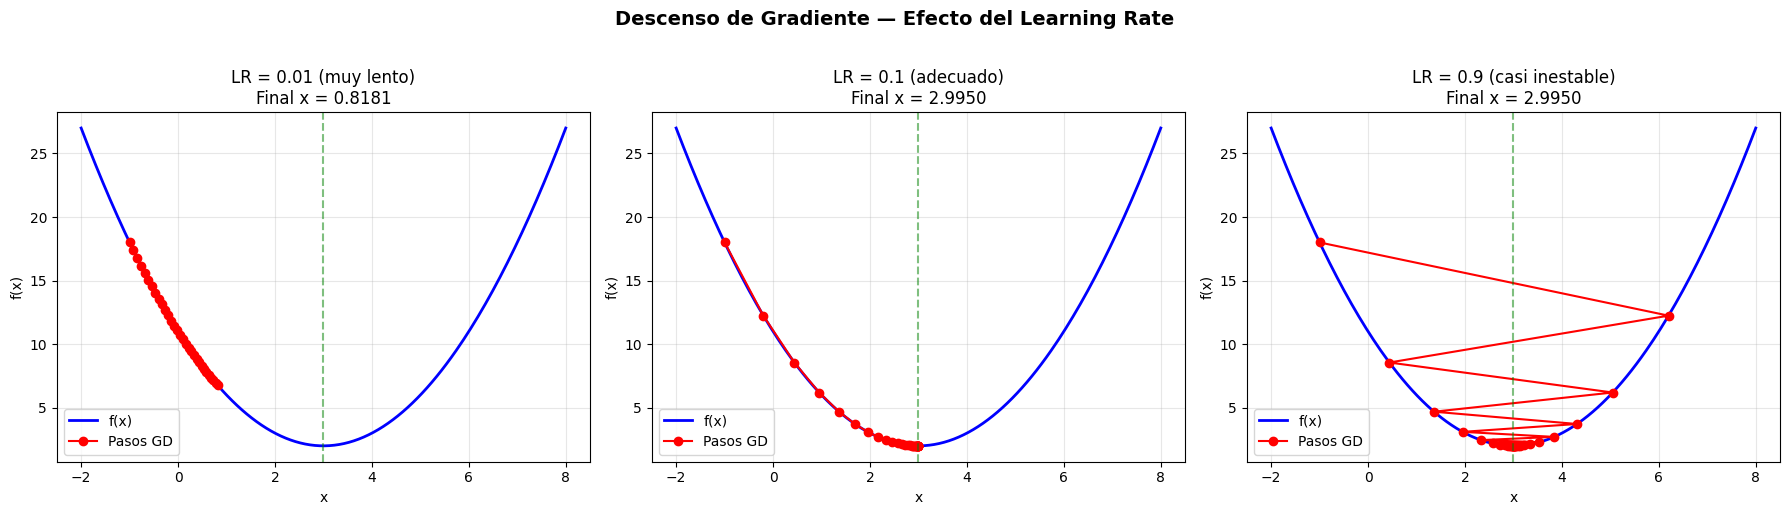

In [14]:
# --- Ejecutar con diferentes learning rates ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x_range = np.linspace(-2, 8, 200)
configs = [
    (0.01, "LR = 0.01 (muy lento)"),
    (0.1,  "LR = 0.1 (adecuado)"),
    (0.9,  "LR = 0.9 (casi inestable)"),
]

for ax, (lr, title) in zip(axes, configs):
    history = gradient_descent(x_init=-1.0, lr=lr, n_steps=30)

    ax.plot(x_range, f(x_range), 'b-', linewidth=2, label='f(x)')
    ax.plot(history, [f(x) for x in history], 'ro-', markersize=6, label='Pasos GD')
    ax.set_title(f'{title}\nFinal x = {history[-1]:.4f}', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axvline(x=3, color='green', linestyle='--', alpha=0.5, label='Mínimo real')

plt.suptitle('Descenso de Gradiente — Efecto del Learning Rate',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Preguntas:**
- ¿Con LR=0.01, llegó al mínimo en 30 pasos? No, todavía no llega al mínimo; avanza muy lento y en 30 pasos solo alcanzó aproximadamente x = 0.8181, lejos de x = 3. 
- ¿Con LR=0.9, qué le pasa? ¿Converge o rebota? Sí converge, pero rebota alrededor del mínimo porque los pasos son muy grandes; aun así termina muy cerca de x = 3.
- ¿Cuál es el LR óptimo para esta función? Sí converge, pero rebota alrededor del mínimo porque los pasos son muy grandes; aun así termina muy cerca de x = 3.


---
## Ejercicio 5 (DESAFÍO): MLP para dataset de lunas

Crea un dataset de "medias lunas" y entrena un MLP para clasificarlo.
Se te da el dataset y la clase MLP ya implementada. Tu tarea:
1. Generar el dataset
2. Elegir la arquitectura correcta
3. Encontrar el learning rate adecuado
4. Lograr **accuracy > 90%**


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# --- Generador de dataset de lunas ---
def make_moons(n=200, noise=0.15):
    """Genera dos medias lunas entrelazadas."""
    t = np.linspace(0, np.pi, n)

    # Luna superior
    x1 = np.cos(t) + np.random.randn(n) * noise
    y1 = np.sin(t) + np.random.randn(n) * noise

    # Luna inferior
    x2 = 1 - np.cos(t) + np.random.randn(n) * noise
    y2 = -np.sin(t) + 0.5 + np.random.randn(n) * noise

    X = np.vstack([
        np.column_stack([x1, y1]),
        np.column_stack([x2, y2])
    ])
    y = np.concatenate([np.zeros(n), np.ones(n)])

    idx = np.random.permutation(len(y))
    return X[idx], y[idx]

# --- Clase MLP ---
class MLP:
    def __init__(self, layer_sizes, lr=0.01):
        self.lr = lr
        self.losses = []
        self.weights = []
        self.biases = []

        for i in range(len(layer_sizes) - 1):
            scale = np.sqrt(2.0 / layer_sizes[i])
            self.weights.append(
                np.random.randn(layer_sizes[i], layer_sizes[i + 1]) * scale
            )
            self.biases.append(np.zeros((1, layer_sizes[i + 1])))

    def relu(self, z):
        return np.maximum(0, z)

    def relu_deriv(self, z):
        return (z > 0).astype(float)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def forward(self, X):
        self.acts = [X]
        self.zs = []
        curr = X

        for i in range(len(self.weights)):
            z = curr @ self.weights[i] + self.biases[i]
            self.zs.append(z)

            if i == len(self.weights) - 1:
                curr = self.sigmoid(z)
            else:
                curr = self.relu(z)

            self.acts.append(curr)

        return curr

    def backward(self, X, y):
        m = len(y)
        y = y.reshape(-1, 1)

        delta = self.acts[-1] - y

        for i in reversed(range(len(self.weights))):
            dW = self.acts[i].T @ delta / m
            db = np.sum(delta, axis=0, keepdims=True) / m

            if i > 0:
                delta = (delta @ self.weights[i].T) * self.relu_deriv(self.zs[i - 1])

            self.weights[i] -= self.lr * dW
            self.biases[i] -= self.lr * db

    def train(self, X, y, epochs=3000):
        for ep in range(epochs):
            pred = self.forward(X)

            eps = 1e-8
            loss = -np.mean(
                y.reshape(-1, 1) * np.log(pred + eps) +
                (1 - y.reshape(-1, 1)) * np.log(1 - pred + eps)
            )

            self.losses.append(loss)
            self.backward(X, y)

            if ep % 600 == 0:
                acc = np.mean((pred.flatten() > 0.5) == y) * 100
                print(f"Epoch {ep:4d} | Loss: {loss:.4f} | Acc: {acc:.2f}%")

        final_pred = self.forward(X).flatten()
        acc = np.mean((final_pred > 0.5) == y) * 100
        print(f"\n>>> FINAL Accuracy: {acc:.2f}%")

    def predict(self, X):
        return self.forward(X).flatten()

# ============================================
#   ENTRENAMIENTO
# ============================================

np.random.seed(42)
X_moons, y_moons = make_moons(200, noise=0.15)

# Normalización
X_mean = X_moons.mean(axis=0)
X_std = X_moons.std(axis=0)
X_norm = (X_moons - X_mean) / X_std

# Crear modelo
model = MLP(layer_sizes=[2, 16, 8, 1], lr=0.1)

# Entrenar
model.train(X_norm, y_moons, epochs=3000)

Epoch    0 | Loss: 2.9916 | Acc: 20.75%
Epoch  600 | Loss: 0.0622 | Acc: 98.50%
Epoch 1200 | Loss: 0.0219 | Acc: 99.50%
Epoch 1800 | Loss: 0.0135 | Acc: 99.50%
Epoch 2400 | Loss: 0.0093 | Acc: 100.00%

>>> FINAL Accuracy: 100.00%


In [16]:
# --- MLP ya implementada (la misma de la clase) ---
class MLP:
    def __init__(self, layer_sizes, lr=0.01):
        self.lr = lr
        self.losses = []
        self.weights = []
        self.biases = []
        for i in range(len(layer_sizes) - 1):
            scale = np.sqrt(2.0 / layer_sizes[i])
            self.weights.append(np.random.randn(layer_sizes[i], layer_sizes[i + 1]) * scale)
            self.biases.append(np.zeros((1, layer_sizes[i + 1])))

    def relu(self, z): return np.maximum(0, z)
    def relu_deriv(self, z): return (z > 0).astype(float)
    def sigmoid(self, z): return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def forward(self, X):
        self.acts = [X]
        self.zs = []
        curr = X
        for i in range(len(self.weights)):
            z = curr @ self.weights[i] + self.biases[i]
            self.zs.append(z)
            curr = self.sigmoid(z) if i == len(self.weights) - 1 else self.relu(z)
            self.acts.append(curr)
        return curr

    def backward(self, X, y):
        m = len(y)
        y = y.reshape(-1, 1)
        delta = self.acts[-1] - y
        for i in reversed(range(len(self.weights))):
            dW = self.acts[i].T @ delta / m
            db = np.sum(delta, axis=0, keepdims=True) / m
            if i > 0:
                delta = (delta @ self.weights[i].T) * self.relu_deriv(self.zs[i - 1])
            self.weights[i] -= self.lr * dW
            self.biases[i] -= self.lr * db

    def train(self, X, y, epochs=2000, verbose=True):
        for ep in range(epochs):
            pred = self.forward(X)
            eps = 1e-8
            loss = -np.mean(y.reshape(-1,1)*np.log(pred+eps) + (1-y.reshape(-1,1))*np.log(1-pred+eps))
            self.losses.append(loss)
            self.backward(X, y)
            if verbose and ep % (epochs//5) == 0:
                acc = np.mean((pred.flatten() > 0.5) == y) * 100
                print(f"Epoch {ep:5d} | Loss: {loss:.4f} | Acc: {acc:.1f}%")
        acc = np.mean((self.forward(X).flatten() > 0.5) == y) * 100
        print(f"\n>>> FINAL Accuracy: {acc:.1f}%")

    def predict(self, X): return self.forward(X).flatten()

In [17]:
# ============================================
#   TU TAREA: Configura y entrena el modelo
# ============================================

# 1. Normalizar los datos
X_mean = X_moons.mean(axis=0)
X_std = X_moons.std(axis=0)
X_norm = (X_moons - X_mean) / X_std

# 2. Arquitectura
ARQUITECTURA = [2, 16, 8, 1]

# 3. Learning rate
LEARNING_RATE = 0.1

# 4. Cantidad de épocas
EPOCHS = 3000

# 5. Crear y entrenar
np.random.seed(42)
model = MLP(layer_sizes=ARQUITECTURA, lr=LEARNING_RATE)
model.train(X_norm, y_moons, epochs=EPOCHS)

Epoch     0 | Loss: 1.6359 | Acc: 44.5%
Epoch   600 | Loss: 0.0688 | Acc: 98.2%
Epoch  1200 | Loss: 0.0272 | Acc: 99.2%
Epoch  1800 | Loss: 0.0181 | Acc: 99.5%
Epoch  2400 | Loss: 0.0138 | Acc: 99.8%

>>> FINAL Accuracy: 99.8%


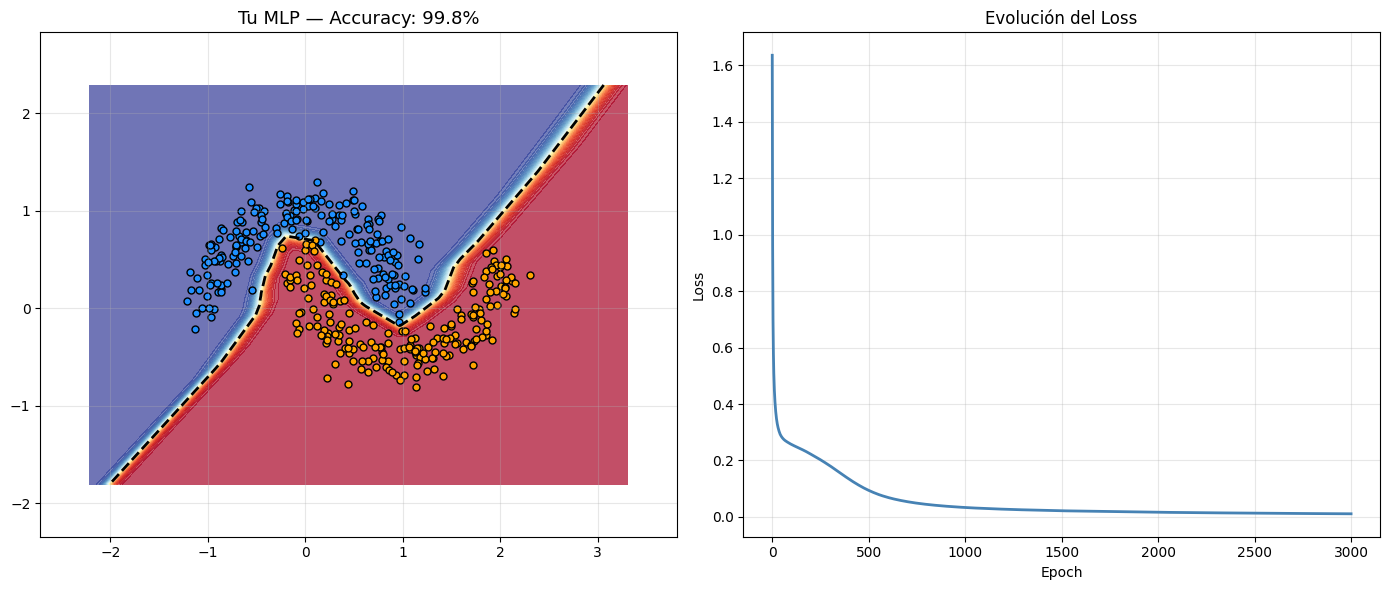

🎉 ¡Excelente! Lograste más del 90% de accuracy!


In [18]:
# --- Visualizar tu resultado ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Frontera
ax = axes[0]
xx, yy = np.meshgrid(
    np.linspace(X_moons[:,0].min()-1, X_moons[:,0].max()+1, 300),
    np.linspace(X_moons[:,1].min()-1, X_moons[:,1].max()+1, 300))
grid_norm = (np.c_[xx.ravel(), yy.ravel()] - X_mean) / X_std
zz = model.predict(grid_norm).reshape(xx.shape)

ax.contourf(xx, yy, zz, levels=50, cmap='RdYlBu_r', alpha=0.7)
ax.contour(xx, yy, zz, levels=[0.5], colors='black', linewidths=2, linestyles='--')
ax.scatter(X_moons[y_moons==0,0], X_moons[y_moons==0,1], c='dodgerblue', edgecolors='k', s=25)
ax.scatter(X_moons[y_moons==1,0], X_moons[y_moons==1,1], c='orange', edgecolors='k', s=25)
pred = model.predict(X_norm)
acc = np.mean((pred > 0.5) == y_moons) * 100
ax.set_title(f'Tu MLP — Accuracy: {acc:.1f}%', fontsize=13)
ax.axis('equal')
ax.grid(True, alpha=0.3)

# Loss
axes[1].plot(model.losses, linewidth=2, color='steelblue')
axes[1].set_title('Evolución del Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

if acc >= 90:
    print("🎉 ¡Excelente! Lograste más del 90% de accuracy!")
elif acc >= 75:
    print("👍 Buen intento. Prueba con más neuronas o ajusta el learning rate.")
else:
    print("🔧 Sigue experimentando. Prueba arquitecturas como [2, 16, 8, 1] y LR entre 0.1 y 1.0")

---
## Pistas para el Ejercicio 5

<details>
<summary>📌 Pista 1: Arquitectura</summary>

Prueba `[2, 16, 8, 1]` — 2 capas ocultas con 16 y 8 neuronas.
</details>

<details>
<summary>📌 Pista 2: Learning rate</summary>

Un valor entre 0.3 y 1.0 suele funcionar bien. Si el loss oscila, bájalo.
</details>

<details>
<summary>📌 Pista 3: Épocas</summary>

Entre 2000 y 4000 debería ser suficiente para converger.
</details>

---
**¡Buena suerte!** 🚀